# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

## Load files 

In [2]:
# Specify the directory containing your CSV files
directory = '../data/stocks'

# Create an empty list to store individual DataFrames
dataframes = []

# Loop through all CSV files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):
        # Extract symbol from filename (remove .csv extension)
        symbol = filename.replace('.csv', '')
        
        # Load the CSV file
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        
        # Add a symbol column to identify the source
        df['symbol'] = symbol
        
        # Append to our list of dataframes
        dataframes.append(df)

# Concatenate all DataFrames in the list
df = pd.concat(dataframes, ignore_index=True)

# Display the first few rows of the merged DataFrame
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,symbol
0,1986-11-17,0.0,2.166667,2.125000,2.125000,1.630455,314400,OSUR
1,1986-11-18,0.0,2.000000,1.916667,1.916667,1.470606,138900,OSUR
2,1986-11-19,0.0,2.000000,1.916667,1.916667,1.470606,141300,OSUR
3,1986-11-20,0.0,2.041667,2.000000,2.000000,1.534545,181500,OSUR
4,1986-11-21,0.0,2.166667,2.125000,2.125000,1.630455,132300,OSUR


In [3]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,symbol
46214,2020-03-26,44.279999,45.349998,44.279999,45.049999,45.049999,2320100,YUMC
46215,2020-03-27,44.020000,44.189999,41.700001,42.560001,42.560001,3007300,YUMC
46216,2020-03-30,42.150002,43.000000,41.549999,42.310001,42.310001,2288100,YUMC
46217,2020-03-31,41.880001,43.755001,41.330002,42.630001,42.630001,2657700,YUMC
46218,2020-04-01,41.200001,42.150002,40.439999,40.990002,40.990002,3219700,YUMC


In [4]:
#checking the columns information(names & Data Types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46219 entries, 0 to 46218
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       46219 non-null  object 
 1   Open       46219 non-null  float64
 2   High       46219 non-null  float64
 3   Low        46219 non-null  float64
 4   Close      46219 non-null  float64
 5   Adj Close  46219 non-null  float64
 6   Volume     46219 non-null  int64  
 7   symbol     46219 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 2.8+ MB


In [5]:
df.shape

(46219, 8)

In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,46219.000000,46219.000000,46219.000000,46219.000000,46219.000000,4.621900e+04
mean,135.548414,141.496225,132.547102,135.235423,131.174341,8.345491e+05
std,398.376292,416.691781,381.095302,394.696225,395.796420,1.936744e+06
min,0.000000,0.900000,0.600000,0.820000,0.122869,0.000000e+00
25%,8.110086,8.560000,8.250000,8.390000,5.201762,1.000000e+02
50%,18.950001,19.209999,18.750000,19.000000,11.988636,2.970000e+04
75%,44.424999,45.264999,43.884645,44.439999,40.000629,6.812500e+05
max,9840.000000,11040.000000,9120.000000,9984.000000,9981.818359,8.770920e+07


In [7]:
# Missing values in each column
missing_values = df.isnull().sum()
print("Missing Values by Column:")
print(missing_values)

Missing Values by Column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
symbol       0
dtype: int64


In [8]:
# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'])


df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,symbol
0,1986-11-17,0.0,2.166667,2.125000,2.125000,1.630455,314400,OSUR
1,1986-11-18,0.0,2.000000,1.916667,1.916667,1.470606,138900,OSUR
2,1986-11-19,0.0,2.000000,1.916667,1.916667,1.470606,141300,OSUR
3,1986-11-20,0.0,2.041667,2.000000,2.000000,1.534545,181500,OSUR
4,1986-11-21,0.0,2.166667,2.125000,2.125000,1.630455,132300,OSUR


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46219 entries, 0 to 46218
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       46219 non-null  datetime64[ns]
 1   Open       46219 non-null  float64       
 2   High       46219 non-null  float64       
 3   Low        46219 non-null  float64       
 4   Close      46219 non-null  float64       
 5   Adj Close  46219 non-null  float64       
 6   Volume     46219 non-null  int64         
 7   symbol     46219 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 2.8+ MB


In [10]:
# The top 10 highest stocks 
top_10_stocks = df.sort_values(by='Close', ascending=False).head(10)

In [11]:
top_10_stocks

,Date,Open,High,Low,Close,Adj Close,Volume,symbol
42385,2008-06-24,9840.000000,11040.000000,9120.000000,9984.000000,9981.818359,6200,YUMA
42384,2008-06-23,7363.200195,9117.599609,7111.200195,9117.599609,9115.607422,3200,YUMA
42389,2008-06-30,8793.599609,9192.000000,8577.599609,8868.000000,8866.062500,1600,YUMA
42390,2008-07-01,9348.000000,9348.000000,8282.400391,8520.000000,8518.138672,1400,YUMA
42388,2008-06-27,8400.000000,8865.599609,8332.799805,8455.200195,8453.352539,1700,YUMA
42386,2008-06-25,9196.799805,9240.000000,7682.399902,8385.599609,8383.767578,4200,YUMA
42387,2008-06-26,8860.799805,9254.400391,7800.000000,8184.000000,8182.211914,2600,YUMA
42381,2008-06-18,6352.799805,7836.000000,6120.000000,7274.399902,7272.810547,5100,YUMA
42383,2008-06-20,7200.000000,7392.000000,6638.399902,7116.000000,7114.445312,1900,YUMA
42391,2008-07-02,8796.000000,8796.000000,6720.000000,6720.000000,6718.531738,2000,YUMA


In [12]:
top_5_stocks = df.sort_values(by='Close', ascending=False).head(5)

In [13]:
print(top_5_stocks)

            Date         Open          High          Low        Close  \
42385 2008-06-24  9840.000000  11040.000000  9120.000000  9984.000000   
42384 2008-06-23  7363.200195   9117.599609  7111.200195  9117.599609   
42389 2008-06-30  8793.599609   9192.000000  8577.599609  8868.000000   
42390 2008-07-01  9348.000000   9348.000000  8282.400391  8520.000000   
42388 2008-06-27  8400.000000   8865.599609  8332.799805  8455.200195   

         Adj Close  Volume symbol  
42385  9981.818359    6200   YUMA  
42384  9115.607422    3200   YUMA  
42389  8866.062500    1600   YUMA  
42390  8518.138672    1400   YUMA  
42388  8453.352539    1700   YUMA  


In [14]:
top5_by_company = df.groupby('symbol').apply(lambda x: x.nlargest(5, 'Close')).reset_index(drop=True)
top5_by_company

C:\Users\Nana\AppData\Local\Temp\ipykernel_18008\2032387409.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top5_by_company = df.groupby('symbol').apply(lambda x: x.nlargest(5, 'Close')).reset_index(drop=True)


,Date,Open,High,Low,Close,Adj Close,Volume,symbol
0,1992-01-15,26.750000,27.375000,26.500000,27.000000,20.716364,152700,OSUR
1,1992-01-07,25.125000,26.625000,25.125000,26.500000,20.332727,218300,OSUR
2,1992-01-14,25.375000,26.875000,25.375000,26.500000,20.332727,114200,OSUR
3,1991-11-14,22.125000,26.125000,20.625000,26.000000,19.949091,441900,OSUR
4,1992-01-08,26.250000,27.500000,25.500000,26.000000,19.949091,191800,OSUR
5,2005-08-02,48.799999,49.910000,48.799999,49.900002,15.708561,79600,PEI
6,2005-07-11,48.980000,49.630001,48.980000,49.560001,15.601542,199000,PEI
7,2005-08-03,49.869999,50.200001,49.490002,49.520000,15.588941,92200,PEI
8,2005-07-28,48.619999,49.480000,48.580002,49.480000,15.576351,234800,PEI
9,2005-07-12,49.360001,49.650002,49.080002,49.110001,15.459870,85300,PEI


In [15]:
lowest5_by_company = df.groupby('symbol').apply(lambda x: x.nsmallest(5, 'Close')).reset_index(drop=True)
lowest5_by_company

C:\Users\Nana\AppData\Local\Temp\ipykernel_18008\1428688234.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lowest5_by_company = df.groupby('symbol').apply(lambda x: x.nsmallest(5, 'Close')).reset_index(drop=True)


,Date,Open,High,Low,Close,Adj Close,Volume,symbol
0,1987-01-09,0.000000,1.916667,1.791667,1.791667,1.374697,36600,OSUR
1,1987-01-12,0.000000,1.916667,1.791667,1.791667,1.374697,1500,OSUR
2,1987-01-16,0.000000,1.875000,1.791667,1.791667,1.374697,26400,OSUR
3,1987-01-19,0.000000,1.916667,1.791667,1.791667,1.374697,6300,OSUR
4,1987-01-06,0.000000,1.916667,1.833333,1.833333,1.406667,12300,OSUR
5,2020-03-18,1.180000,1.180000,0.800000,0.820000,0.820000,4054100,PEI
6,2020-04-01,0.870000,0.900000,0.830000,0.880000,0.880000,1639900,PEI
7,2020-03-30,0.930000,0.950000,0.850000,0.900000,0.900000,1935400,PEI
8,2020-03-31,0.850000,0.910000,0.840000,0.910000,0.910000,2080800,PEI
9,2020-03-27,1.060000,1.070000,0.900000,0.930000,0.930000,1898800,PEI


## Check for Consistency

In [16]:
# Check if High is always >= Low, Open, and Close
inconsistent_high = df[
    (df['High'] < df['Low']) | 
    (df['High'] < df['Open']) | 
    (df['High'] < df['Close'])
]

print(f"Number of rows where High is not the highest price: {len(inconsistent_high)}")
if len(inconsistent_high) > 0:
    print("Sample inconsistent rows:")
    print(inconsistent_high.head())

# Check if Low is always <= High, Open, and Close
inconsistent_low = df[
    (df['Low'] > df['High']) | 
    (df['Low'] > df['Open']) | 
    (df['Low'] > df['Close'])
]

print(f"Number of rows where Low is not the lowest price: {len(inconsistent_low)}")
if len(inconsistent_low) > 0:
    print("Sample inconsistent rows:")
    print(inconsistent_low.head())


Number of rows where High is not the highest price: 0
Number of rows where Low is not the lowest price: 1259
Sample inconsistent rows:
        Date  Open      High       Low     Close  Adj Close  Volume symbol
0 1986-11-17   0.0  2.166667  2.125000  2.125000   1.630455  314400   OSUR
1 1986-11-18   0.0  2.000000  1.916667  1.916667   1.470606  138900   OSUR
2 1986-11-19   0.0  2.000000  1.916667  1.916667   1.470606  141300   OSUR
3 1986-11-20   0.0  2.041667  2.000000  2.000000   1.534545  181500   OSUR
4 1986-11-21   0.0  2.166667  2.125000  2.125000   1.630455  132300   OSUR


Quality Checks

In [17]:
duplicates = df.duplicated()


print(f"Number of duplicate rows: {duplicates.sum()}")

# Get the duplicate rows
duplicate_rows = df[duplicates]


print("\nDuplicate rows:")
print(duplicate_rows)

Number of duplicate rows: 0

Duplicate rows:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, symbol]
Index: []


In [18]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,46219,46219.000000,46219.000000,46219.000000,46219.000000,46219.000000,4.621900e+04
mean,2004-06-24 07:48:42.668166656,135.548414,141.496225,132.547102,135.235423,131.174341,8.345491e+05
min,1973-05-03 00:00:00,0.000000,0.900000,0.600000,0.820000,0.122869,0.000000e+00
25%,1995-05-17 00:00:00,8.110086,8.560000,8.250000,8.390000,5.201762,1.000000e+02
50%,2007-03-22 00:00:00,18.950001,19.209999,18.750000,19.000000,11.988636,2.970000e+04
75%,2015-05-11 00:00:00,44.424999,45.264999,43.884645,44.439999,40.000629,6.812500e+05
max,2020-04-01 00:00:00,9840.000000,11040.000000,9120.000000,9984.000000,9981.818359,8.770920e+07
std,NaN,398.376292,416.691781,381.095302,394.696225,395.796420,1.936744e+06


## Standardize column names

In [19]:
print("Original Column Names:")
print(df.columns.tolist())


# Convert to lowercase and replace spaces with underscores
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# Check the standardized column names
print("\nStandardized Column Names:")
print(df.columns.tolist())


Original Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'symbol']

Standardized Column Names:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'symbol']


In [20]:
# Save the cleaned dataset
df.to_csv('../data/cleaned_data.csv')

Visualization

In [26]:
file_path = "../data/cleaned_data.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

In [29]:
filtered = df[df['symbol'] == "YUMC"]


In [30]:
filtered

,Unnamed: 0,date,open,high,low,close,adj_close,volume,symbol
45349,45349,2016-10-17,30.000000,30.000000,25.650000,25.650000,24.946878,251900,YUMC
45350,45350,2016-10-18,26.172001,26.172001,23.790001,24.440001,23.770044,349300,YUMC
45351,45351,2016-10-19,24.860001,24.860001,24.150000,24.260000,23.594978,222700,YUMC
45352,45352,2016-10-20,24.260000,24.260000,24.260000,24.260000,23.594978,0,YUMC
45353,45353,2016-10-21,24.250000,25.110001,24.250000,24.920000,24.236885,354600,YUMC
...,...,...,...,...,...,...,...,...,...
46214,46214,2020-03-26,44.279999,45.349998,44.279999,45.049999,45.049999,2320100,YUMC
46215,46215,2020-03-27,44.020000,44.189999,41.700001,42.560001,42.560001,3007300,YUMC
46216,46216,2020-03-30,42.150002,43.000000,41.549999,42.310001,42.310001,2288100,YUMC
46217,46217,2020-03-31,41.880001,43.755001,41.330002,42.630001,42.630001,2657700,YUMC


Time Series Plot

C:\Users\Nana\AppData\Local\Temp\ipykernel_18008\2260992156.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['date'] = pd.to_datetime(filtered['date'])


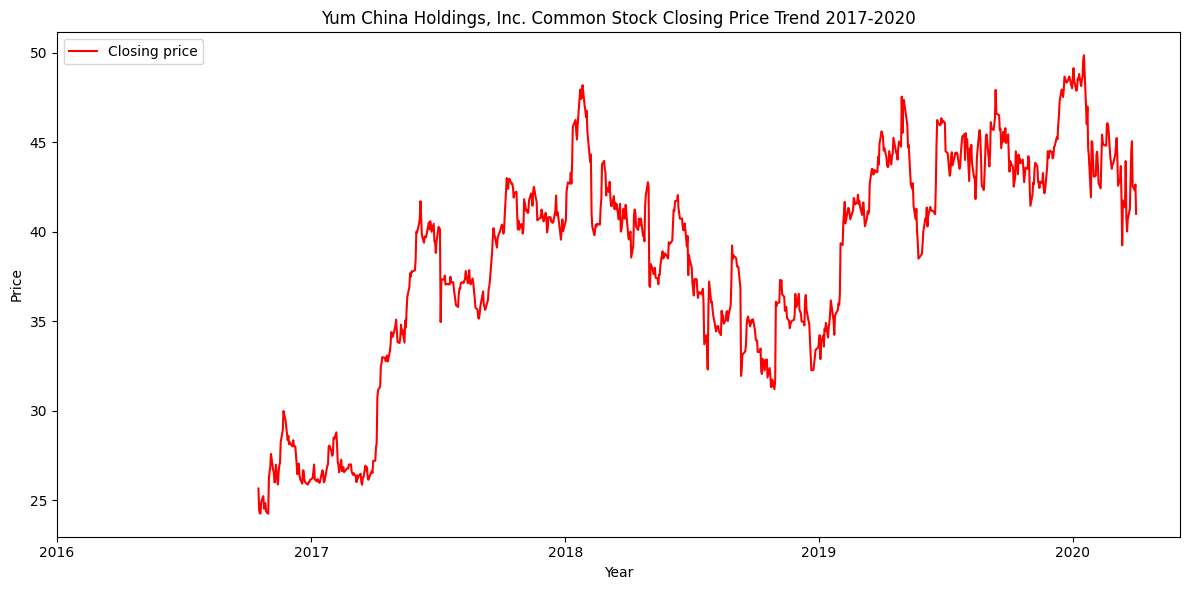

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure 'date' column is datetime
filtered['date'] = pd.to_datetime(filtered['date'])

# Extract unique years from the date column
years = sorted(filtered['date'].dt.year.unique())

# Create list of dates corresponding to Jan 1st of each year (or approximate)
year_ticks = [pd.Timestamp(f'{year}-01-01') for year in years]

# Time series plot
plt.figure(figsize=(12,6))
plt.plot(filtered['date'], filtered['close'], label='Closing price', color='red')

# Set x-ticks to only those specific years
plt.xticks(ticks=year_ticks, labels=years)

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Yum China Holdings, Inc. Common Stock Closing Price Trend 2017-2020')
plt.legend()
plt.tight_layout()
plt.show()


Stock Price Correlation Heatmap

Unnamed: 0      int64
date           object
open          float64
high          float64
low           float64
close         float64
adj_close     float64
volume          int64
symbol         object
dtype: object


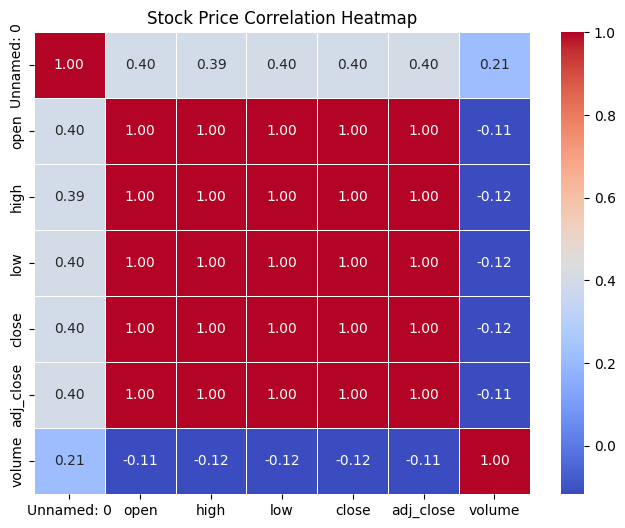

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load stock data from local Parquet file
file_path = "../data/cleaned_data.csv"
df = pd.read_csv(file_path)

# Check the column names and data types
print(df.dtypes)

# Filter only the numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Stock Price Correlation Heatmap")
plt.show()
